# Test Visual Prompting

Build (query crop, target image, ground-truth boxes) triplets from `Voxel51/LVIS`.

`Voxel51/LVIS` is a FiftyOne-formatted dataset, so it must be loaded via
`fiftyone.utils.huggingface.load_from_hub` rather than `datasets.load_dataset`.
Each sample exposes:

- `sample.filepath` — local path to the downloaded image
- `sample.detections.detections[j].label` — class name
- `sample.detections.detections[j].bounding_box` — `[x, y, w, h]` normalized to `[0, 1]`

In [1]:
import random
from PIL import Image

import fiftyone as fo
import fiftyone.utils.huggingface as fouh

# Voxel51/LVIS is FiftyOne-formatted (samples.json + media files), not Parquet.
# Use a small max_samples while iterating; raise it when you're ready.
DATASET_NAME = "Voxel51/LVIS"
MAX_SAMPLES = 1000

# `load_from_hub` caches the dataset locally and downloads media on demand.
# `overwrite=True` avoids "dataset already exists" errors on re-runs.
dataset = fouh.load_from_hub(
    DATASET_NAME,
    max_samples=MAX_SAMPLES,
    overwrite=True,
)
dataset

Loading dataset
Importing samples...
 100% |███████████████| 1000/1000 [178.6ms elapsed, 0s remaining, 5.6K samples/s]      
Migrating dataset 'Voxel51/LVIS' to v1.15.0


Name:        Voxel51/LVIS
Media type:  image
Num samples: 1000
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    detections:       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    segmentations:    fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Polylines)

In [2]:
# Build an inverted index: class_label -> list of (sample_id, detection_idx).
# We iterate once and stash sample IDs so we can fetch full samples (and crop
# the right detection) later without re-scanning the dataset.
class_to_dets: dict[str, list[tuple[str, int]]] = {}

for sample in dataset.iter_samples(progress=True):
    dets = sample.detections.detections if sample.detections is not None else None
    if not dets:
        continue
    for j, det in enumerate(dets):
        class_to_dets.setdefault(det.label, []).append((sample.id, j))

print(f"indexed {sum(len(v) for v in class_to_dets.values())} detections "
      f"across {len(class_to_dets)} classes")

 100% |███████████████| 1000/1000 [6.6s elapsed, 0s remaining, 148.2 samples/s]      
indexed 11672 detections across 527 classes


In [3]:
def _denorm_bbox(bbox, w, h):
    """FiftyOne stores [x, y, w, h] normalized to [0, 1]. Convert to (x1, y1, x2, y2) pixels."""
    x, y, bw, bh = bbox
    return (x * w, y * h, (x + bw) * w, (y + bh) * h)


def sample_visual_prompt_triplet(rng: random.Random | None = None):
    """Return (query_crop, target_image, gt_boxes_xyxy, class_label).

    - query_crop: PIL image cropped to one detection of the chosen class
    - target_image: a *different* image containing the same class
    - gt_boxes_xyxy: all bounding boxes (in pixel coords) of that class in the target
    """
    rng = rng or random

    # Need a class that appears in at least 2 distinct images so query != target.
    eligible = [c for c, locs in class_to_dets.items()
                if len({sid for sid, _ in locs}) >= 2]
    if not eligible:
        raise RuntimeError("no class has detections in 2+ distinct images; raise MAX_SAMPLES")
    
    cls = rng.choice(eligible)
    locs = class_to_dets[cls]

    # Pick two distinct sample IDs, then a random detection index inside the query.
    distinct_sids = list({sid for sid, _ in locs})
    q_sid, t_sid = rng.sample(distinct_sids, 2)
    q_j = rng.choice([j for sid, j in locs if sid == q_sid])

    q_sample = dataset[q_sid]
    q_img = Image.open(q_sample.filepath).convert("RGB")
    q_det = q_sample.detections.detections[q_j]
    query_crop = q_img.crop(_denorm_bbox(q_det.bounding_box, *q_img.size))

    t_sample = dataset[t_sid]
    t_img = Image.open(t_sample.filepath).convert("RGB")
    gt_boxes = [
        _denorm_bbox(d.bounding_box, *t_img.size)
        for d in t_sample.detections.detections
        if d.label == cls
    ]

    return query_crop, t_img, gt_boxes, cls

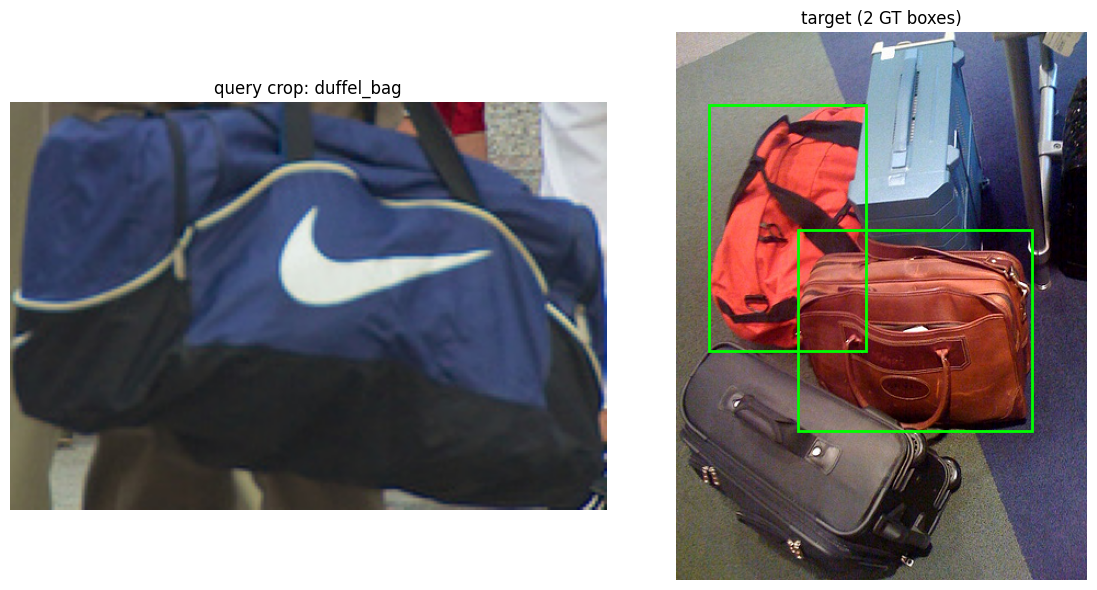

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

query_crop, target_img, gt_boxes, cls = sample_visual_prompt_triplet(random.Random(5))

fig, (ax_q, ax_t) = plt.subplots(1, 2, figsize=(12, 6))
ax_q.imshow(query_crop)
ax_q.set_title(f"query crop: {cls}")
ax_q.axis("off")

ax_t.imshow(target_img)
for x1, y1, x2, y2 in gt_boxes:
    ax_t.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                             fill=False, edgecolor="lime", linewidth=2))
ax_t.set_title(f"target ({len(gt_boxes)} GT boxes)")
ax_t.axis("off")
plt.tight_layout()
plt.show()

## Diagnostic: is the visual-prompt slot even close to the text-prompt slot?

Before changing `detect()` to accept a query image, we want a cheap sanity signal.
The architectural plan would replace the text-token embeddings of the class label
with `mean_pool(vision_encoder(query_crop))` inside the `detect` template:

```
[image patches] [detect prefix] [* class label *] [detect suffix] -> (x, y, w, h)+
                                ^^^^^^^^^^^^^^^^^
                  text path:    text_encoder(" dog")
                  visual path:  mean(vision_encoder(query_crop))
```

Two questions to answer before doing any model surgery:

1. **Cosine probe (cheap).** When we mean-pool the projected visual tokens for a
   crop of class `c`, is the resulting `(1, D)` vector closer to `text_encoder(" c")`
   than to other class labels? If yes, the two spaces are at least loosely aligned.
2. **End-to-end probe.** Splice the pooled query embedding into the actual detect
   template and run `_generate_points` zero-shot. If it produces *any* sane boxes
   without fine-tuning, that's a strong signal. If it produces nothing or random
   coordinates, fine-tuning is required (expected outcome).

In [7]:
import torch
import torch.nn.functional as F
from safetensors.torch import load_file

from moondream2.moondream import MoondreamModel, MoondreamConfig
from moondream2.text import text_encoder, lm_head

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

mdl = MoondreamModel(config=MoondreamConfig(), setup_caches=True)
mdl.load_state_dict(load_file("moondream2/model.safetensors"))
mdl.to(DEVICE)
for _, buf in mdl.named_buffers():
    buf.data = buf.data.to(DEVICE)
mdl.eval()
print(f"loaded moondream2 on {DEVICE}")

loaded moondream2 on mps


In [8]:
@torch.inference_mode()
def text_emb_pooled(model: MoondreamModel, label: str) -> torch.Tensor:
    """Mean-pool the text-encoder embeddings of ' {label}' to a single (1, D) vector.

    The leading space matches what `detect()` does internally:
        tokenizer.encode(" " + object).ids
    """
    ids = model.tokenizer.encode(" " + label).ids
    ids_t = torch.tensor([ids], device=model.device)
    emb = text_encoder(ids_t, model.text)          # (1, T_text, D)
    return emb.mean(dim=1)                          # (1, D)


@torch.inference_mode()
def vision_emb_pooled(model: MoondreamModel, image: Image.Image) -> torch.Tensor:
    """Mean-pool the projected vision-encoder output to a single (1, D) vector.

    `_run_vision_encoder` returns a (729, D) tensor of patch embeddings already
    in text-decoder-input space (after `vision_projection`).
    """
    tokens = model._run_vision_encoder(image)       # (729, D)
    return tokens.mean(dim=0, keepdim=True)         # (1, D)


_demo_text = text_emb_pooled(mdl, "dog")
_demo_vis  = vision_emb_pooled(mdl, query_crop)
print(f"text_emb shape:   {tuple(_demo_text.shape)}, dtype={_demo_text.dtype}")
print(f"vision_emb shape: {tuple(_demo_vis.shape)},  dtype={_demo_vis.dtype}")
print(f"raw cosine(' dog' text vs query crop): "
      f"{F.cosine_similarity(_demo_text, _demo_vis, dim=-1).item():+.4f}")

text_emb shape:   (1, 2048), dtype=torch.bfloat16
vision_emb shape: (1, 2048),  dtype=torch.bfloat16
raw cosine(' dog' text vs query crop): +0.1084


In [9]:
# Cosine-probe: zero-shot retrieval of class label from a pooled query crop.
#
# For each candidate class with >=5 distinct images, sample N crops, mean-pool
# their projected vision embeddings, and rank against the mean-pooled text
# embeddings of all candidate class names. Report top-1 / top-5.

# LVIS class names use underscores and occasional parentheses; clean to
# something the tokenizer handles sensibly.
def _label_clean(c: str) -> str:
    return c.replace("_", " ").split("(")[0].strip()


candidate_classes = sorted(
    c for c in class_to_dets
    if all(ch.isalnum() or ch in " _-" for ch in c)
    and len({sid for sid, _ in class_to_dets[c]}) >= 5
)
# Cap vocab for speed; expand later if you want a harder retrieval task.
VOCAB = candidate_classes[:60]
print(f"vocab size: {len(VOCAB)}; first 10: {VOCAB[:10]}")

text_bank = torch.cat(
    [text_emb_pooled(mdl, _label_clean(c)) for c in VOCAB], dim=0
)                                                        # (V, D)
text_bank = F.normalize(text_bank, dim=-1)

rng = random.Random(0)
N_PER_CLASS = 3
top1 = top5 = total = 0
per_class_correct: dict[str, tuple[int, int]] = {}

for cls in VOCAB:
    sids = list({sid for sid, _ in class_to_dets[cls]})
    sampled_sids = rng.sample(sids, min(N_PER_CLASS, len(sids)))
    correct, n = 0, 0
    for sid in sampled_sids:
        j = rng.choice([j for s, j in class_to_dets[cls] if s == sid])
        sample = dataset[sid]
        img = Image.open(sample.filepath).convert("RGB")
        det = sample.detections.detections[j]
        crop = img.crop(_denorm_bbox(det.bounding_box, *img.size))

        q = F.normalize(vision_emb_pooled(mdl, crop), dim=-1)
        sims = (q @ text_bank.T).squeeze(0)              # (V,)
        ranking = torch.argsort(sims, descending=True).tolist()
        gt_idx = VOCAB.index(cls)

        if ranking[0] == gt_idx: top1 += 1; correct += 1
        if gt_idx in ranking[:5]: top5 += 1
        total += 1
        n += 1
    per_class_correct[cls] = (correct, n)

print(f"\nTop-1: {top1}/{total} = {top1/total:.1%}")
print(f"Top-5: {top5}/{total} = {top5/total:.1%}")
print(f"Random baseline top-1 = {1/len(VOCAB):.1%}, top-5 = {5/len(VOCAB):.1%}")

# Spot-check a few classes.
print("\nper-class top-1 (sample):")
for cls in rng.sample(list(per_class_correct), min(15, len(per_class_correct))):
    c, n = per_class_correct[cls]
    print(f"  {cls:30s} {c}/{n}")

vocab size: 60; first 10: ['airplane', 'apple', 'armchair', 'awning', 'backpack', 'banana', 'banner', 'baseball', 'baseball_base', 'baseball_bat']

Top-1: 5/180 = 2.8%
Top-5: 18/180 = 10.0%
Random baseline top-1 = 1.7%, top-5 = 8.3%

per-class top-1 (sample):
  bottle_cap                     0/3
  armchair                       0/3
  bicycle                        0/3
  blanket                        0/3
  clock_tower                    0/3
  choker                         0/3
  baseball_bat                   0/3
  baseball_cap                   0/3
  cat                            0/3
  cake                           0/3
  book                           0/3
  control                        3/3
  banana                         0/3
  backpack                       0/3
  cup                            0/3


In [10]:
# Sanity check: replay `detect()` via our manual prefill path, but feed the
# text embedding for " {label}" into the same slot where `detect_with_visual_prompt`
# splices the pooled vision embedding. If our plumbing is correct, this should
# produce boxes very similar to `model.detect(target_image, object=label)`.
#
# Why this matters: if `detect_with_visual_prompt` looks broken in cell 9, this
# tells us whether the bug is in (a) the manual prefill mechanics — wrong mask /
# pos_ids / hidden indexing — or (b) actually in the "use a vision embedding as
# the prompt" idea. Only (b) is interesting.

@torch.inference_mode()
def detect_with_text_prompt_manual(
    model: MoondreamModel,
    target_image: Image.Image,
    label: str,
    max_objects: int = 25,
) -> list[dict]:
    encoded = model.encode_image(target_image)
    model.load_encoded_image(encoded)

    prefix_ids = model.config.tokenizer.templates["detect"]["prefix"]
    suffix_ids = model.config.tokenizer.templates["detect"]["suffix"]
    label_ids = model.tokenizer.encode(" " + label).ids

    pre = text_encoder(torch.tensor([prefix_ids], device=model.device), model.text)
    lab = text_encoder(torch.tensor([label_ids], device=model.device), model.text)
    suf = text_encoder(torch.tensor([suffix_ids], device=model.device), model.text)
    prompt_emb = torch.cat([pre, lab, suf], dim=1)

    pos = encoded.pos
    L = prompt_emb.size(1)
    mask = model.attn_mask[:, :, pos : pos + L, :]
    pos_ids = torch.arange(pos, pos + L, device=model.device, dtype=torch.long)

    hidden = model._prefill(prompt_emb, mask, pos_ids)
    logits = lm_head(hidden, model.text)
    next_token = torch.argmax(logits, dim=-1).unsqueeze(1)
    return model._generate_points(
        hidden[:, -1:, :], next_token, pos + L,
        include_size=True, max_objects=max_objects,
    )


_label = _label_clean(cls)
manual_boxes  = detect_with_text_prompt_manual(mdl, target_img, _label)
official_boxes = mdl.detect(target_img, object=_label)["objects"]

print(f"label fed to detect: {_label!r}")
print(f"  manual prefill path : {len(manual_boxes)} boxes")
print(f"  official model.detect: {len(official_boxes)} boxes")
print()
print("Boxes should match closely. If counts are wildly different (e.g. 0 vs 5,")
print("or 25 vs 2), the bug is in manual prefill — not in visual prompting.")

label fed to detect: 'cup'
  manual prefill path : 0 boxes
  official model.detect: 0 boxes

Boxes should match closely. If counts are wildly different (e.g. 0 vs 5,
or 25 vs 2), the bug is in manual prefill — not in visual prompting.


In [11]:
# End-to-end probe: splice the pooled query embedding into the actual `detect`
# template and run `_generate_points`. This is exactly the architectural change
# we'd make to `detect()`, but performed externally with no model edits.
#
# Returns a list of {x_min, y_min, x_max, y_max} dicts, like model.detect(...)["objects"].

@torch.inference_mode()
def detect_with_visual_prompt(
    model: MoondreamModel,
    target_image: Image.Image,
    query_image: Image.Image,
    max_objects: int = 25,
) -> list[dict]:
    encoded = model.encode_image(target_image)
    model.load_encoded_image(encoded)

    prefix_ids = model.config.tokenizer.templates["detect"]["prefix"]
    suffix_ids = model.config.tokenizer.templates["detect"]["suffix"]

    pre_emb = text_encoder(torch.tensor([prefix_ids], device=model.device), model.text)
    suf_emb = text_encoder(torch.tensor([suffix_ids], device=model.device), model.text)
    q_emb = vision_emb_pooled(model, query_image).unsqueeze(0)   # (1, 1, D)

    prompt_emb = torch.cat([pre_emb, q_emb, suf_emb], dim=1)     # (1, L, D)

    pos = encoded.pos
    L = prompt_emb.size(1)
    mask = model.attn_mask[:, :, pos : pos + L, :]
    pos_ids = torch.arange(pos, pos + L, device=model.device, dtype=torch.long)

    hidden = model._prefill(prompt_emb, mask, pos_ids)            # (1, L, D)
    logits = lm_head(hidden, model.text)                          # (1, V)
    next_token = torch.argmax(logits, dim=-1).unsqueeze(1)        # (1, 1)
    last_hidden = hidden[:, -1:, :]
    pos = pos + L

    return model._generate_points(
        last_hidden, next_token, pos, include_size=True, max_objects=max_objects,
    )


# Run on the same triplet we visualized earlier and compare with text-prompted
# detect on the same target.
text_objects = mdl.detect(target_img, object=_label_clean(cls))["objects"]
visual_objects = detect_with_visual_prompt(mdl, target_img, query_crop)

print(f"class: {cls!r} (label fed to text detect: {_label_clean(cls)!r})")
print(f"  text-prompted detect:   {len(text_objects)} boxes")
print(f"  visual-prompted detect: {len(visual_objects)} boxes")
print(f"  ground truth:           {len(gt_boxes)} boxes")

class: 'cup' (label fed to text detect: 'cup')
  text-prompted detect:   0 boxes
  visual-prompted detect: 4 boxes
  ground truth:           2 boxes


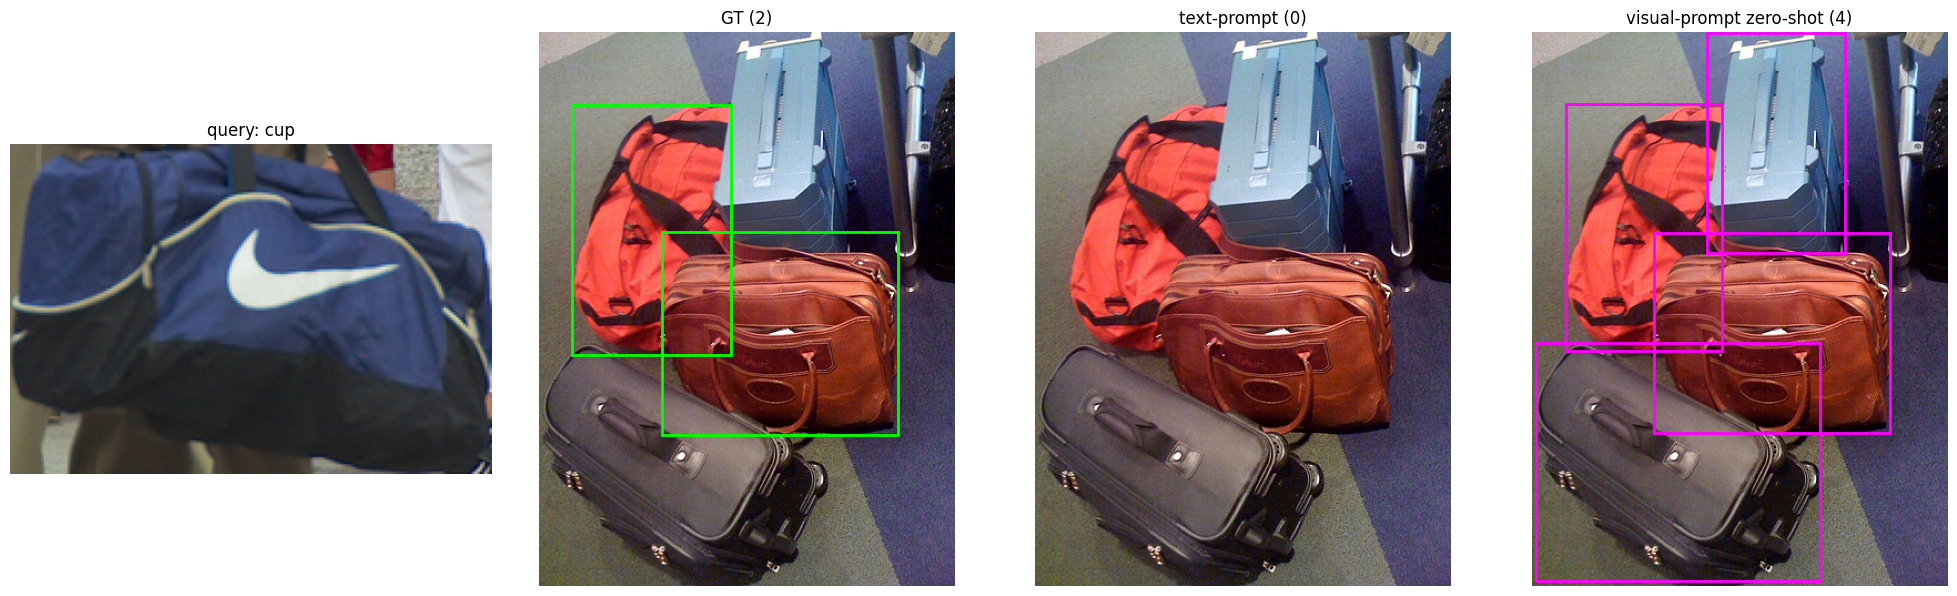

In [12]:
# Side-by-side visualization: GT, text-prompted detect, visual-prompted detect.
def _draw(ax, img, boxes_norm, color, title):
    ax.imshow(img)
    W, H = img.size
    for b in boxes_norm:
        if isinstance(b, dict):
            x1, y1, x2, y2 = b["x_min"] * W, b["y_min"] * H, b["x_max"] * W, b["y_max"] * H
        else:
            x1, y1, x2, y2 = b
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, edgecolor=color, linewidth=2))
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(query_crop); axes[0].set_title(f"query: {cls}"); axes[0].axis("off")
_draw(axes[1], target_img, gt_boxes,       "lime",    f"GT ({len(gt_boxes)})")
_draw(axes[2], target_img, text_objects,   "cyan",    f"text-prompt ({len(text_objects)})")
_draw(axes[3], target_img, visual_objects, "magenta", f"visual-prompt zero-shot ({len(visual_objects)})")
plt.tight_layout()
plt.show()